In [1]:
# STEP 1: IMPORTING LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# STEP 2: LOADING DATASET

df = pd.read_csv(r"D:\AI ML\DiabetesKaggle.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:\n")
print(df.head())

Dataset Shape: (100000, 9)

First 5 Rows:

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  Outcome  
0          6.6                  140        0  
1          6.6                   80        0  
2          5.7                  158        0  
3          5.0                  155        0  
4          4.8                  155        0  


In [3]:
# STEP 3: HANDLING MISSING VALUES

print("Missing Values Before Handling:\n")
print(df.isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype == "object":
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())

print("\nMissing Values After Handling:\n")
print(df.isnull().sum())

Missing Values Before Handling:

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
Outcome                0
dtype: int64

Missing Values After Handling:

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
Outcome                0
dtype: int64


In [4]:
# STEP 4: REMOVING OUTLIERS

outlier_cols = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]

rows_before = df.shape[0]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

rows_after = df.shape[0]

print("Rows before:", rows_before)
print("Rows after :", rows_after)
print("Outliers removed:", rows_before - rows_after)

df.reset_index(drop=True, inplace=True)

Rows before: 100000
Rows after : 90387
Outliers removed: 9613


In [5]:
# STEP 5: ENCODING CATEGORICAL COLUMNS

df = pd.get_dummies(df, columns=["gender", "smoking_history"], drop_first=True)

print("Dataset Shape After Encoding:", df.shape)
print("\nColumns:\n")
print(df.columns)

Dataset Shape After Encoding: (90387, 14)

Columns:

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'Outcome', 'gender_Male', 'gender_Other',
       'smoking_history_current', 'smoking_history_ever',
       'smoking_history_former', 'smoking_history_never',
       'smoking_history_not current'],
      dtype='object')


In [6]:
# STEP 6: SELECTING FINAL FEATURES AND TARGET

X_selected_raw = df[["HbA1c_level", "blood_glucose_level", "bmi", "age"]]
y = df["Outcome"]

print("Selected Features:\n")
print(X_selected_raw.head())

print("\nTarget Values:\n")
print(y.head())

Selected Features:

   HbA1c_level  blood_glucose_level    bmi   age
0          6.6                  140  25.19  80.0
1          6.6                   80  27.32  54.0
2          5.7                  158  27.32  28.0
3          5.0                  155  23.45  36.0
4          4.8                  155  20.14  76.0

Target Values:

0    0
1    0
2    0
3    0
4    0
Name: Outcome, dtype: int64


In [7]:
# STEP 7: USING TRAIN-TEST SPLIT

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_selected_raw, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train_raw Shape:", X_train_raw.shape)
print("X_test_raw Shape :", X_test_raw.shape)
print("y_train Shape    :", y_train.shape)
print("y_test Shape     :", y_test.shape)

X_train_raw Shape: (72309, 4)
X_test_raw Shape : (18078, 4)
y_train Shape    : (72309,)
y_test Shape     : (18078,)


In [8]:
# STEP 8: SCALING THE SELECTED FEATURES

scaler_selected = StandardScaler()

X_train = scaler_selected.fit_transform(X_train_raw)
X_test = scaler_selected.transform(X_test_raw)

X_train = pd.DataFrame(X_train, columns=X_selected_raw.columns, index=X_train_raw.index)
X_test = pd.DataFrame(X_test, columns=X_selected_raw.columns, index=X_test_raw.index)

print("Scaled Training Data:\n")
print(X_train.head())

Scaled Training Data:

       HbA1c_level  blood_glucose_level       bmi       age
33208    -1.966363            -1.406429  0.564002  0.914608
59890     0.547245             0.578815 -0.439224  1.314222
89969    -0.458198            -0.130201  2.346373  0.248584
67358    -0.960920             0.578815 -1.306767 -0.461841
7267      0.647789            -0.243643  0.204239  0.825805


In [9]:
# STEP 9: CREATING MODEL EVALUATION FUNCTION

def evaluate_model(model_name, y_test, y_pred):
    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n{model_name} PERFORMANCE")
    print("-" * 40)
    print("Accuracy :", round(acc, 4))
    print("Precision:", round(pre, 4))
    print("Recall   :", round(rec, 4))
    print("F1-Score :", round(f1, 4))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

    return acc, pre, rec, f1

In [10]:
# STEP 10: TRAINING LOGISTIC REGRESSION MODEL

lr_model = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully")

Logistic Regression Model Trained Successfully


In [11]:
# STEP 11: LOGISTIC REGRESSION PREDICTION

y_pred_lr = lr_model.predict(X_test)

print("First 10 Predictions:\n")
print(y_pred_lr[:10])

First 10 Predictions:

[0 0 0 0 0 1 1 0 0 0]



Logistic Regression PERFORMANCE
----------------------------------------
Accuracy : 0.8329
Precision: 0.2121
Recall   : 0.8687
F1-Score : 0.3409

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.83      0.90     17179
           1       0.21      0.87      0.34       899

    accuracy                           0.83     18078
   macro avg       0.60      0.85      0.62     18078
weighted avg       0.95      0.83      0.88     18078

Confusion Matrix:
 [[14277  2902]
 [  118   781]]


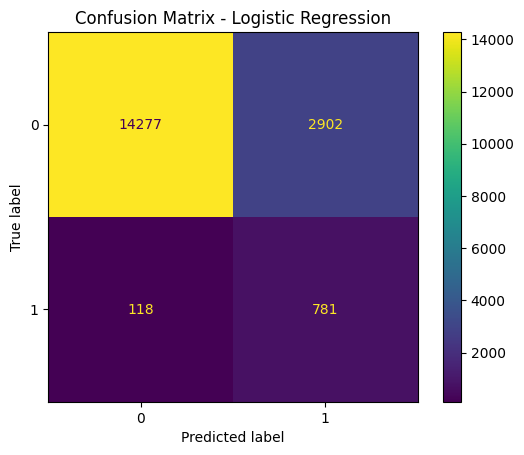

In [12]:
# STEP 12: LOGISTIC REGRESSION EVALUATION

lr_acc, lr_pre, lr_rec, lr_f1 = evaluate_model("Logistic Regression", y_test, y_pred_lr)

In [13]:
# STEP 13: FINDING BEST K FOR KNN

k_values = []
k_accuracies = []
k_recalls = []
k_f1_scores = []

for k in range(1, 16, 2):
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    y_pred_temp = knn_temp.predict(X_test)

    acc_temp = accuracy_score(y_test, y_pred_temp)
    rec_temp = recall_score(y_test, y_pred_temp, zero_division=0)
    f1_temp = f1_score(y_test, y_pred_temp, zero_division=0)

    k_values.append(k)
    k_accuracies.append(acc_temp)
    k_recalls.append(rec_temp)
    k_f1_scores.append(f1_temp)

    print(f"K = {k} --> Accuracy = {acc_temp:.4f}, Recall = {rec_temp:.4f}, F1-Score = {f1_temp:.4f}")

best_k = k_values[k_f1_scores.index(max(k_f1_scores))]

print("\nBest K Value:", best_k)

K = 1 --> Accuracy = 0.9533, Recall = 0.5072, F1-Score = 0.5191
K = 3 --> Accuracy = 0.9653, Recall = 0.4616, F1-Score = 0.5693
K = 5 --> Accuracy = 0.9684, Recall = 0.4449, F1-Score = 0.5835
K = 7 --> Accuracy = 0.9695, Recall = 0.4283, F1-Score = 0.5829
K = 9 --> Accuracy = 0.9696, Recall = 0.4138, F1-Score = 0.5750
K = 11 --> Accuracy = 0.9699, Recall = 0.4105, F1-Score = 0.5752
K = 13 --> Accuracy = 0.9691, Recall = 0.3993, F1-Score = 0.5623
K = 15 --> Accuracy = 0.9689, Recall = 0.3882, F1-Score = 0.5540

Best K Value: 5


In [14]:
# STEP 14: TRAINING KNN MODEL

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


In [15]:
# STEP 15: KNN PREDICTION

y_pred_knn = knn_model.predict(X_test)

print("First 10 Predictions:\n")
print(y_pred_knn[:10])

First 10 Predictions:

[0 0 0 0 0 0 0 0 0 0]



KNN PERFORMANCE
----------------------------------------
Accuracy : 0.9684
Precision: 0.8475
Recall   : 0.4449
F1-Score : 0.5835

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17179
           1       0.85      0.44      0.58       899

    accuracy                           0.97     18078
   macro avg       0.91      0.72      0.78     18078
weighted avg       0.97      0.97      0.96     18078

Confusion Matrix:
 [[17107    72]
 [  499   400]]


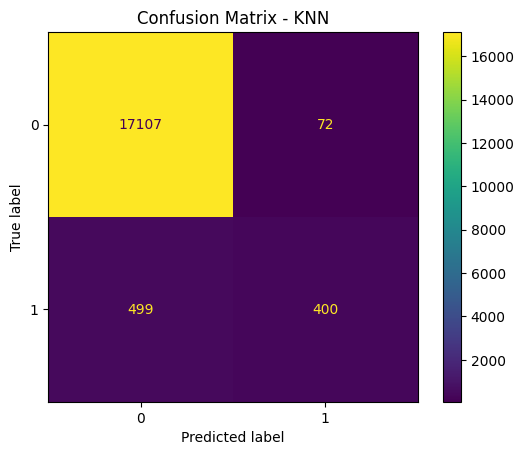

In [16]:
# STEP 16: KNN EVALUATION

knn_acc, knn_pre, knn_rec, knn_f1 = evaluate_model("KNN", y_test, y_pred_knn)

In [17]:
# STEP 17: TRAINING SVM MODEL

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [18]:
# STEP 18: SVM PREDICTION

y_pred_svm = svm_model.predict(X_test)

print("First 10 Predictions:\n")
print(y_pred_svm[:10])

First 10 Predictions:

[1 0 0 0 0 1 1 0 0 0]



SVM PERFORMANCE
----------------------------------------
Accuracy : 0.829
Precision: 0.2146
Recall   : 0.9166
F1-Score : 0.3478

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.82      0.90     17179
           1       0.21      0.92      0.35       899

    accuracy                           0.83     18078
   macro avg       0.60      0.87      0.62     18078
weighted avg       0.96      0.83      0.87     18078

Confusion Matrix:
 [[14163  3016]
 [   75   824]]


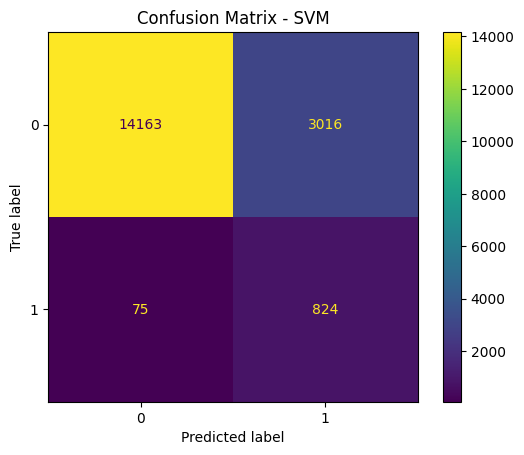

In [19]:
# STEP 19: SVM EVALUATION

svm_acc, svm_pre, svm_rec, svm_f1 = evaluate_model("SVM", y_test, y_pred_svm)

In [20]:
# STEP 20: COMPARING ALL 3 MODELS

results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "SVM"],
    "Accuracy": [lr_acc, knn_acc, svm_acc],
    "Precision": [lr_pre, knn_pre, svm_pre],
    "Recall": [lr_rec, knn_rec, svm_rec],
    "F1-Score": [lr_f1, knn_f1, svm_f1]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1-Score
0  Logistic Regression  0.832946   0.212055  0.868743  0.340899
1                  KNN  0.968415   0.847458  0.444939  0.583516
2                  SVM  0.829019   0.214583  0.916574  0.347753


In [21]:
# STEP 21: FINDING BEST MODEL OUT OF THREE (LOGISTIC REGRESSION ,KNN ,SVM)

best_model_row = results.loc[results["F1-Score"].idxmax()]

print("Best Model Based On F1-Score:\n")
print(best_model_row)

Best Model Based On F1-Score:

Model             KNN
Accuracy     0.968415
Precision    0.847458
Recall       0.444939
F1-Score     0.583516
Name: 1, dtype: object


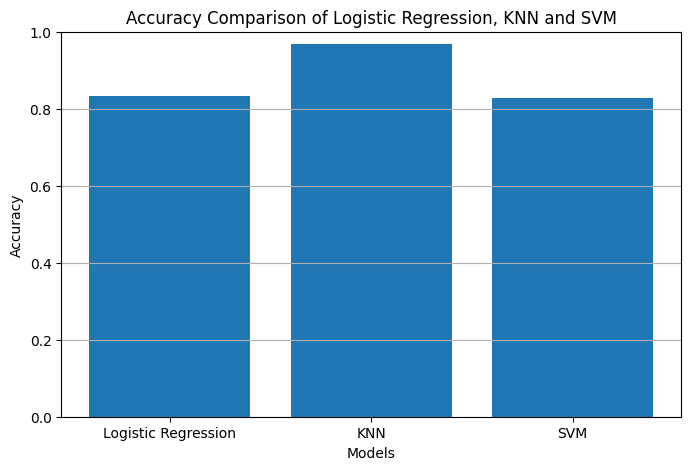

In [22]:
# STEP 22: ACCURACY COMPARISON GRAPH

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Logistic Regression, KNN and SVM")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()

In [23]:
# STEP 23: RAW USER INPUT PREPROCESSING

raw_input_dict = {}

for col in X_selected_raw.columns:
    if col == "HbA1c_level":
        raw_input_dict[col] = float(input("Enter HbA1c_level: "))
    elif col == "blood_glucose_level":
        raw_input_dict[col] = float(input("Enter blood_glucose_level: "))
    elif col == "bmi":
        raw_input_dict[col] = float(input("Enter bmi: "))
    elif col == "age":
        raw_input_dict[col] = float(input("Enter age: "))

raw_input_df = pd.DataFrame([raw_input_dict])

print("\nRaw Input Data:\n")
print(raw_input_df)

user_input_scaled = scaler_selected.transform(raw_input_df)
user_input_scaled_df = pd.DataFrame(user_input_scaled, columns=X_selected_raw.columns)

print("\nScaled Input Data:\n")
print(user_input_scaled_df)

Enter HbA1c_level:  3.3
Enter blood_glucose_level:  4.5
Enter bmi:  30
Enter age:  42



Raw Input Data:

   HbA1c_level  blood_glucose_level   bmi   age
0          3.3                  4.5  30.0  42.0

Scaled Input Data:

   HbA1c_level  blood_glucose_level       bmi       age
0    -2.167452             -3.68946  0.755191  0.026576


In [24]:
# STEP 24: FINAL PREDICTION USING BEST MODEL

best_model_name = best_model_row["Model"]

if best_model_name == "Logistic Regression":
    final_prediction = lr_model.predict(user_input_scaled_df)[0]
elif best_model_name == "KNN":
    final_prediction = knn_model.predict(user_input_scaled_df)[0]
else:
    final_prediction = svm_model.predict(user_input_scaled_df)[0]

print("\nPrediction From Best Model:", final_prediction)

if final_prediction == 1:
    print("The patient is predicted as Diabetic")
else:
    print("The patient is predicted as Non-Diabetic")


Prediction From Best Model: 0
The patient is predicted as Non-Diabetic
